# N06A — Performance Ceiling and External Benchmark

## Purpose

N06 is an **exploratory, post-hoc performance extension**. It does **not** replace, modify, or reinterpret the locked N00–N05 scientific pipeline.

The question is deliberately different from N05:

> **How high can OAI → NHANES III KL-grading performance go when the model is optimized for ordinal predictive performance rather than constrained to the original concept-bottleneck pathway?**

N06 uses a direct ConvNeXt-Base KL pathway and screens three OAI-only variants:

1. **baseline_ce** — direct five-class KL classification;
2. **ordinal_rank** — direct KL classification + CORAL-style ordinal supervision + continuous severity + pairwise ranking;
3. **hybrid_concepts** — the ordinal model plus auxiliary osteophyte, sclerosis, and JSN heads wherever those OAI labels are available.

The best variant is selected **only on OAI validation QWK**. It is then retrained with all three fixed thesis seeds, ensembled, assigned OAI-validation-fitted ordinal cut-points, evaluated once on OAI test, and finally evaluated zero-shot on the N01 NHANES cohort.

### Important interpretation rule

The published Li et al. 2026 preprint value of **0.8640 external QWK** is retained only as a benchmark reference. N06 does **not** claim a direct replication unless the external cohort and quality-control protocol are demonstrably aligned.


## N06 locked protocol

Before any NHANES labels are loaded, N06 fixes:

- source: OAI only for training, validation, model selection and ordinal threshold fitting;
- backbone family: ConvNeXt-Base, ImageNet pretrained;
- input: 448 × 448 center crop at evaluation, 512 → 448 crop during training;
- patient-level OAI split: 70% train / 15% validation / 15% test;
- candidate variants: baseline CE, ordinal/ranking, hybrid concepts;
- candidate selection: highest OAI validation QWK, then lower MAE, then lower severe-error rate;
- final seeds: `367761876`, `1767922150`, `1023912954`;
- optimizer: AdamW with warm-up + cosine decay;
- regularization: label smoothing, affine/color augmentation, horizontal flip, Random Erasing, stochastic depth, MixUp;
- final inference: three-seed equal-weight ensemble + horizontal-flip TTA;
- ordinal cut-points: optimized on OAI validation only and frozen before external evaluation;
- external evaluation: zero-shot; NHANES is never used for training, early stopping, model selection, calibration, or threshold fitting.

A configuration hash, source-manifest hash, split hash, selected-variant record, and final lock file are written to Google Drive.


In [1]:
# 0. Environment and reproducibility

from __future__ import annotations

import copy
import csv
import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable
from IPython.display import display
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

# Install timm only when absent. The rest are standard Colab packages.
try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm>=1.0.11'])
    import timm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.optimize import differential_evolution

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, *args, **kwargs):
        return x

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

if not torch.cuda.is_available():
    raise RuntimeError('N06 requires a CUDA GPU runtime.')

DEVICE = torch.device('cuda')
GPU_NAME = torch.cuda.get_device_name(0)
AMP_DTYPE = torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
SCALER_ENABLED = AMP_DTYPE == torch.float16

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print('GPU:', GPU_NAME)
print('AMP dtype:', AMP_DTYPE)
print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)


Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB
AMP dtype: torch.bfloat16
PyTorch: 2.11.0+cu128
timm: 1.0.28


In [2]:
# 1. Paths, output namespace, and locked configuration

MY_DRIVE = Path('/content/drive/MyDrive')
PROJECT_ROOT = MY_DRIVE / 'Master Thesis'
FINAL_ROOT = MY_DRIVE / 'MasterThesis' / 'Final Pipeline'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Original project root not found: {PROJECT_ROOT}')
if not FINAL_ROOT.exists():
    raise FileNotFoundError(f'Final Pipeline root not found: {FINAL_ROOT}')

OAI_LABELS_PATH = PROJECT_ROOT / 'oai' / 'oai_processed_labels.csv'
OAI_CONCEPTS_PATH = PROJECT_ROOT / 'oai' / 'oai_oarsi_labels.csv'
OAI_IMAGE_DIR = PROJECT_ROOT / 'oai' / 'processed'
N01_NHANES_PATH = FINAL_ROOT / 'data' / 'N01' / 'nhanes_cohort.csv'
NHANES_IMAGE_DIR = PROJECT_ROOT / 'nhanes3' / 'processed'

STAGE = 'N06'
IMPLEMENTATION_REVISION = '2026-08-29_n06_n01_identity_helpers_v2'
PROTOCOL = 'N06_PERFORMANCE_CEILING_V2_20260829'

RESULT_DIR = FINAL_ROOT / 'results' / STAGE
TABLE_DIR = FINAL_ROOT / 'tables' / STAGE
FIGURE_DIR = FINAL_ROOT / 'figures' / STAGE
CHECKPOINT_DIR = FINAL_ROOT / 'checkpoints' / STAGE
PREDICTION_DIR = FINAL_ROOT / 'predictions' / STAGE
MANIFEST_DIR = FINAL_ROOT / 'manifests' / STAGE
CONFIG_DIR = FINAL_ROOT / 'config' / STAGE
LOCAL_CACHE_ROOT = Path('/content/n06_images')

for folder in (
    RESULT_DIR, TABLE_DIR, FIGURE_DIR, CHECKPOINT_DIR, PREDICTION_DIR,
    MANIFEST_DIR, CONFIG_DIR, LOCAL_CACHE_ROOT,
):
    folder.mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class Config:
    protocol: str = PROTOCOL
    image_size: int = 448
    resize_size: int = 512
    train_fraction: float = 0.70
    validation_fraction: float = 0.15
    test_fraction: float = 0.15
    split_seed: int = 20260829
    training_seeds: tuple[int, int, int] = (367761876, 1767922150, 1023912954)

    screen_epochs: int = 18
    final_epochs: int = 100
    min_epochs: int = 8
    patience: int = 10
    warmup_epochs: int = 5

    batch_size_a100: int = 24
    batch_size_other: int = 8
    num_workers: int = 4
    cache_workers: int = 12

    lr: float = 2.0e-4
    weight_decay: float = 5.0e-2
    grad_clip: float = 1.0
    drop_path_rate: float = 0.20
    dropout: float = 0.20
    label_smoothing: float = 0.05

    mixup_probability: float = 0.50
    mixup_alpha: float = 0.20
    random_erasing_probability: float = 0.25

    ema_decay: float = 0.999
    bootstrap_repetitions: int = 2000
    bootstrap_seed: int = 20260829

    # Engineering reference only; never used for model selection.
    li_reference_qwk: float = 0.8640

CONFIG = Config()
BATCH_SIZE = CONFIG.batch_size_a100 if 'A100' in GPU_NAME.upper() else CONFIG.batch_size_other

VARIANTS = {
    'baseline_ce': {
        'ce': 1.00, 'ordinal': 0.00, 'regression': 0.00, 'ranking': 0.00, 'concept': 0.00,
    },
    'ordinal_rank': {
        'ce': 0.60, 'ordinal': 0.20, 'regression': 0.10, 'ranking': 0.10, 'concept': 0.00,
    },
    'hybrid_concepts': {
        'ce': 0.55, 'ordinal': 0.18, 'regression': 0.09, 'ranking': 0.08, 'concept': 0.10,
    },
}

# This is a benchmark reference, not a tuning target.
BENCHMARK_NOTE = (
    'Li et al. 2026 preprint external QWK reference = 0.8640; '
    'test cohort/protocol may differ, so direct superiority is not claimed automatically.'
)

# Resolve a usable pretrained ConvNeXt-Base name without silently changing family.
preferred_backbones = [
    'convnext_base.fb_in22k_ft_in1k',
    'convnext_base.fb_in1k',
    'convnext_base',
]
available = set(timm.list_models(pretrained=True))
BACKBONE_NAME = next((name for name in preferred_backbones if name in available), None)
if BACKBONE_NAME is None:
    base_candidates = [m for m in sorted(available) if m.startswith('convnext_base')]
    if not base_candidates:
        raise RuntimeError('No pretrained ConvNeXt-Base model is available in this timm build.')
    BACKBONE_NAME = base_candidates[0]


def stable_json(value: Any) -> str:
    return json.dumps(value, sort_keys=True, separators=(',', ':'), default=str)


def sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def atomic_json(value: Any, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    tmp.write_text(json.dumps(value, indent=2, sort_keys=True, default=str), encoding='utf-8')
    tmp.replace(path)


def atomic_csv(frame: pd.DataFrame, path: Path) -> None:
    tmp = path.with_suffix(path.suffix + '.tmp')
    frame.to_csv(tmp, index=False)
    tmp.replace(path)

CONFIG_PAYLOAD = {
    'config': asdict(CONFIG),
    'variants': VARIANTS,
    'backbone': BACKBONE_NAME,
    'protocol': PROTOCOL,
    'implementation_revision': IMPLEMENTATION_REVISION,
}
CONFIG_HASH = sha256_bytes(stable_json(CONFIG_PAYLOAD).encode('utf-8'))
atomic_json(CONFIG_PAYLOAD | {'config_sha256': CONFIG_HASH}, CONFIG_DIR / 'n06_config.json')

print('Protocol:', PROTOCOL)
print('Backbone:', BACKBONE_NAME)
print('Batch size:', BATCH_SIZE)
print('Config SHA-256:', CONFIG_HASH)
print(BENCHMARK_NOTE)


Protocol: N06_PERFORMANCE_CEILING_V2_20260829
Backbone: convnext_base.fb_in22k_ft_in1k
Batch size: 24
Config SHA-256: 7d599ff8a4a6853ac0205d1c0c701d2ddcaa3259c90f99b9629bc5bbe795cea9
Li et al. 2026 preprint external QWK reference = 0.8640; test cohort/protocol may differ, so direct superiority is not claimed automatically.


## 2. OAI performance manifest

Unlike N02A, N06 does **not require complete concept labels** for an image to contribute to KL training. Every valid OAI row with:

- a parseable participant identifier,
- a valid KL grade 0–4,
- a resolvable processed image,

is eligible for the direct KL objective. Structural concepts are merged as optional auxiliary labels and are masked when absent.

This is the main data-efficiency change in N06.


In [3]:
# 2. Build the all-KL OAI manifest with optional concept labels
#
# IMPORTANT: filename parsing and side canonicalisation below are copied from the
# accepted N01 cohort-construction logic so N06 uses exactly the same identity rules.

for required in (OAI_LABELS_PATH, OAI_CONCEPTS_PATH, OAI_IMAGE_DIR):
    if not required.exists():
        raise FileNotFoundError(f'Missing N06 source: {required}')

labels_raw = pd.read_csv(OAI_LABELS_PATH, low_memory=False)
concepts_raw = pd.read_csv(OAI_CONCEPTS_PATH, low_memory=False)


def normalize_name(name: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', str(name).lower()).strip('_')


def resolve_unique_column(frame: pd.DataFrame, aliases: Iterable[str], field: str, required: bool = True):
    lookup: dict[str, list[str]] = {}
    for col in frame.columns:
        lookup.setdefault(normalize_name(col), []).append(str(col))
    matches: list[str] = []
    for alias in aliases:
        matches.extend(lookup.get(normalize_name(alias), []))
    matches = sorted(set(matches))
    if len(matches) == 1:
        return matches[0]
    if not required and len(matches) == 0:
        return None
    raise KeyError(
        f'Could not resolve {field} uniquely. Matches={matches}; '
        f'columns={list(frame.columns)}'
    )


def canonical_side(series: pd.Series) -> pd.Series:
    """Exact N01 side canonicalisation."""
    normalized = series.astype('string').str.strip().str.upper()
    mapping = {
        'LEFT': 'L', 'LT': 'L', '1': 'L',
        'RIGHT': 'R', 'RT': 'R', '2': 'R',
    }
    return normalized.replace(mapping)


def parse_oai_filename(filename: Any) -> tuple[str | None, str | None]:
    """Exact N01 OAI filename parser: 7-digit subject + _L_/_R_ side token."""
    text = str(filename)
    subject_match = re.search(r'(\d{7})', text)
    side_match = re.search(r'_(R|L)_', text.upper())
    subject = subject_match.group(1) if subject_match else None
    side = side_match.group(1) if side_match else None
    return subject, side


# Small deterministic compatibility self-test. This catches accidental helper removal
# immediately, before any manifest is written.
_test_side = canonical_side(pd.Series(['LEFT', 'RT', '1', '2', 'L', 'R'])).astype(str).tolist()
if _test_side != ['L', 'R', 'L', 'R', 'L', 'R']:
    raise RuntimeError(f'N01 side canonicalisation self-test failed: {_test_side}')
if parse_oai_filename('prefix_1234567_R_example.png') != ('1234567', 'R'):
    raise RuntimeError('N01 OAI filename parser self-test failed.')

filename_col = resolve_unique_column(
    labels_raw,
    ('filename', 'image', 'image_name', 'filepath', 'path'),
    'OAI filename',
)
kl_col = resolve_unique_column(labels_raw, ('kl_grade', 'kl', 'label', 'grade'), 'OAI KL')

# Build the OAI base table using the same parser used by N01.
parsed = labels_raw[filename_col].astype(str).apply(parse_oai_filename)
OAI_ALL = pd.DataFrame({
    'source_row': np.arange(len(labels_raw), dtype=int),
    'filename': labels_raw[filename_col].astype(str),
    'patient_id': parsed.map(lambda value: value[0]).astype('string'),
    'knee_side': parsed.map(lambda value: value[1]).astype('string'),
    'kl_grade': pd.to_numeric(labels_raw[kl_col], errors='coerce'),
})
OAI_ALL['patient_id'] = OAI_ALL['patient_id'].astype('string').str.strip()

# Resolve concepts using the exact N01 OAI schema.
concept_patient_col = resolve_unique_column(concepts_raw, ('subject_id',), 'OAI concept subject_id')
concept_side_col = resolve_unique_column(concepts_raw, ('side',), 'OAI concept side')
ost_col = resolve_unique_column(concepts_raw, ('osteophyte_max',), 'osteophyte_max')
scl_col = resolve_unique_column(concepts_raw, ('sclerosis_max',), 'sclerosis_max')
jsn_col = resolve_unique_column(concepts_raw, ('jsn_max',), 'jsn_max')

OAI_CONCEPT_TABLE = pd.DataFrame({
    'patient_id': concepts_raw[concept_patient_col].astype('string').str.strip(),
    'knee_side': canonical_side(concepts_raw[concept_side_col]).astype('string'),
    'osteophyte_max': pd.to_numeric(concepts_raw[ost_col], errors='coerce'),
    'sclerosis_max': pd.to_numeric(concepts_raw[scl_col], errors='coerce'),
    'jsn_max': pd.to_numeric(concepts_raw[jsn_col], errors='coerce'),
})
if OAI_CONCEPT_TABLE.duplicated(['patient_id', 'knee_side']).any():
    dup = OAI_CONCEPT_TABLE.loc[
        OAI_CONCEPT_TABLE.duplicated(['patient_id', 'knee_side'], keep=False)
    ]
    display(dup.head(20))
    raise RuntimeError(
        'OAI concept table has duplicate patient-side keys; '
        'N06 refuses an ambiguous merge.'
    )

OAI_ALL = OAI_ALL.merge(
    OAI_CONCEPT_TABLE,
    on=['patient_id', 'knee_side'],
    how='left',
    validate='many_to_one',
)

# Validity gates.
valid_patient = OAI_ALL['patient_id'].notna() & OAI_ALL['patient_id'].str.fullmatch(r'\d{7}', na=False)
valid_side = OAI_ALL['knee_side'].isin(['L', 'R'])
valid_kl = OAI_ALL['kl_grade'].isin([0, 1, 2, 3, 4])

for concept in ('osteophyte_max', 'sclerosis_max', 'jsn_max'):
    invalid = OAI_ALL[concept].notna() & ~OAI_ALL[concept].isin([0, 1, 2, 3])
    OAI_ALL.loc[invalid, concept] = np.nan

OAI_ALL['eligible_metadata'] = valid_patient & valid_side & valid_kl

# Resolve exact processed image paths, without recursive search.
def resolve_exact_image(filename: str, directory: Path) -> Path | None:
    fp = Path(str(filename))
    candidates = [directory / fp, directory / fp.name]
    for candidate in candidates:
        if candidate.exists() and candidate.is_file() and candidate.stat().st_size > 0:
            return candidate.resolve()
    return None


resolved = [
    resolve_exact_image(f, OAI_IMAGE_DIR)
    for f in tqdm(OAI_ALL['filename'], desc='Resolving OAI images')
]
OAI_ALL['source_image_path'] = [str(p) if p is not None else None for p in resolved]
OAI_ALL['image_found'] = OAI_ALL['source_image_path'].notna()
OAI_ALL['eligible'] = OAI_ALL['eligible_metadata'] & OAI_ALL['image_found']

exclusion_summary = pd.DataFrame([
    {'reason': 'all source rows', 'rows': len(OAI_ALL)},
    {'reason': 'invalid/unparseable metadata', 'rows': int((~OAI_ALL['eligible_metadata']).sum())},
    {'reason': 'missing processed image', 'rows': int((OAI_ALL['eligible_metadata'] & ~OAI_ALL['image_found']).sum())},
    {'reason': 'eligible N06 rows', 'rows': int(OAI_ALL['eligible'].sum())},
])
atomic_csv(exclusion_summary, TABLE_DIR / 'T01_oai_accounting.csv')
atomic_csv(OAI_ALL, MANIFEST_DIR / 'oai_all_kl_audit.csv')
display(exclusion_summary)

OAI = OAI_ALL.loc[OAI_ALL['eligible']].copy().reset_index(drop=True)
if OAI.empty:
    raise RuntimeError('N06 found zero eligible OAI knees after metadata and image validation.')
OAI['kl_grade'] = OAI['kl_grade'].astype(int)
OAI['knee_key'] = (
    OAI['patient_id'].astype(str) + '_' + OAI['knee_side'].astype(str) + '_' +
    OAI['filename'].map(lambda x: Path(str(x)).stem)
)
if not OAI['knee_key'].is_unique:
    dup = OAI.loc[
        OAI['knee_key'].duplicated(keep=False),
        ['knee_key', 'filename', 'patient_id', 'knee_side'],
    ]
    display(dup.head(30))
    raise RuntimeError('N06 OAI knee_key is not unique.')

concept_coverage = pd.DataFrame({
    'concept': ['osteophyte_max', 'sclerosis_max', 'jsn_max'],
    'labelled_rows': [
        int(OAI[c].notna().sum())
        for c in ('osteophyte_max', 'sclerosis_max', 'jsn_max')
    ],
    'total_rows': len(OAI),
})
concept_coverage['coverage'] = concept_coverage['labelled_rows'] / concept_coverage['total_rows']
atomic_csv(concept_coverage, TABLE_DIR / 'T02_concept_coverage.csv')
display(concept_coverage)

SOURCE_MANIFEST_HASH = sha256_bytes(
    OAI[['knee_key', 'patient_id', 'filename', 'kl_grade', 'source_image_path']]
    .sort_values('knee_key')
    .to_csv(index=False)
    .encode('utf-8')
)

print('Eligible OAI knees:', len(OAI))
print('OAI patients:', OAI['patient_id'].nunique())
print('Source manifest SHA-256:', SOURCE_MANIFEST_HASH)
if len(OAI) <= 5252:
    print('WARNING: the raw OAI KL source did not expand beyond the N01 concept-complete cohort size.')
else:
    print('Data expansion achieved: N06 can train KL on more OAI knees than the concept-complete N01 cohort.')


Resolving OAI images:   0%|          | 0/8547 [00:00<?, ?it/s]

,reason,rows
0,all source rows,8547
1,invalid/unparseable metadata,0
2,missing processed image,0
3,eligible N06 rows,8547


,concept,labelled_rows,total_rows,coverage
0,osteophyte_max,5253,8547,0.614602
1,sclerosis_max,5252,8547,0.614485
2,jsn_max,8547,8547,1.000000


Eligible OAI knees: 8547
OAI patients: 4301
Source manifest SHA-256: 1d01eabc7d5a7252f3ebf3572aca6368062821fb89627ef06e0f10dba99edb2d
Data expansion achieved: N06 can train KL on more OAI knees than the concept-complete N01 cohort.


## 3. Fresh N06 patient split

N06 uses a fresh split because its eligible OAI universe can be larger than the concept-complete N02A cohort. Splitting occurs at the **participant level**, stratified by each participant's maximum KL grade. The OAI test set is not used for candidate selection.

If the split files already exist, N06 validates their source-manifest hash and refuses to continue if the underlying eligible cohort changed.


In [4]:
# 3. Create or validate the frozen N06 OAI patient split

TRAIN_PATIENTS_PATH = MANIFEST_DIR / 'oai_train_patients.csv'
VAL_PATIENTS_PATH = MANIFEST_DIR / 'oai_validation_patients.csv'
TEST_PATIENTS_PATH = MANIFEST_DIR / 'oai_test_patients.csv'
SPLIT_META_PATH = MANIFEST_DIR / 'oai_split_metadata.json'

patient_table = (
    OAI.groupby('patient_id', as_index=False)
    .agg(patient_max_kl=('kl_grade','max'), knees=('knee_key','size'))
)
patient_table['patient_max_kl'] = patient_table['patient_max_kl'].astype(int)

split_files = [TRAIN_PATIENTS_PATH, VAL_PATIENTS_PATH, TEST_PATIENTS_PATH, SPLIT_META_PATH]
if any(p.exists() for p in split_files):
    if not all(p.exists() for p in split_files):
        raise RuntimeError('Partial N06 split exists. Delete/repair the incomplete split before continuing.')
    meta = json.loads(SPLIT_META_PATH.read_text(encoding='utf-8'))
    if meta.get('source_manifest_sha256') != SOURCE_MANIFEST_HASH:
        raise RuntimeError('Existing N06 split was created from a different OAI source manifest.')
    if meta.get('split_seed') != CONFIG.split_seed:
        raise RuntimeError('Existing N06 split uses a different split seed.')
    train_ids = set(pd.read_csv(TRAIN_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))
    val_ids = set(pd.read_csv(VAL_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))
    test_ids = set(pd.read_csv(TEST_PATIENTS_PATH, dtype='string')['patient_id'].astype(str))
    print('Existing frozen N06 split validated.')
else:
    first = StratifiedShuffleSplit(n_splits=1, test_size=CONFIG.test_fraction, random_state=CONFIG.split_seed)
    dev_idx, test_idx = next(first.split(patient_table, patient_table['patient_max_kl']))
    dev_patients = patient_table.iloc[dev_idx].reset_index(drop=True)
    test_patients = patient_table.iloc[test_idx].reset_index(drop=True)

    val_share_of_dev = CONFIG.validation_fraction / (CONFIG.train_fraction + CONFIG.validation_fraction)
    second = StratifiedShuffleSplit(n_splits=1, test_size=val_share_of_dev, random_state=CONFIG.split_seed + 1)
    train_idx, val_idx = next(second.split(dev_patients, dev_patients['patient_max_kl']))

    train_ids = set(dev_patients.iloc[train_idx]['patient_id'].astype(str))
    val_ids = set(dev_patients.iloc[val_idx]['patient_id'].astype(str))
    test_ids = set(test_patients['patient_id'].astype(str))

    atomic_csv(pd.DataFrame({'patient_id':sorted(train_ids)}), TRAIN_PATIENTS_PATH)
    atomic_csv(pd.DataFrame({'patient_id':sorted(val_ids)}), VAL_PATIENTS_PATH)
    atomic_csv(pd.DataFrame({'patient_id':sorted(test_ids)}), TEST_PATIENTS_PATH)

    atomic_json({
        'protocol': PROTOCOL,
        'created_utc': datetime.now(timezone.utc).isoformat(),
        'source_manifest_sha256': SOURCE_MANIFEST_HASH,
        'split_seed': CONFIG.split_seed,
        'fractions': {
            'train': CONFIG.train_fraction,
            'validation': CONFIG.validation_fraction,
            'test': CONFIG.test_fraction,
        },
    }, SPLIT_META_PATH)

all_patients = set(patient_table['patient_id'].astype(str))
if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
    raise RuntimeError('N06 patient split overlap detected.')
if train_ids | val_ids | test_ids != all_patients:
    raise RuntimeError('N06 patient split does not cover the eligible OAI patient universe.')

OAI['model_split'] = np.select([
    OAI['patient_id'].astype(str).isin(train_ids),
    OAI['patient_id'].astype(str).isin(val_ids),
    OAI['patient_id'].astype(str).isin(test_ids),
], ['train','validation','test'], default='unassigned')
if OAI['model_split'].eq('unassigned').any():
    raise RuntimeError('Unassigned OAI rows remain after split.')

split_summary = OAI.groupby('model_split').agg(knees=('knee_key','size'), patients=('patient_id','nunique')).reset_index()
class_summary = OAI.groupby(['model_split','kl_grade']).size().reset_index(name='knees')
atomic_csv(split_summary, TABLE_DIR / 'T03_oai_split_summary.csv')
atomic_csv(class_summary, TABLE_DIR / 'T04_oai_split_class_distribution.csv')
display(split_summary)

SPLIT_HASH = sha256_bytes(
    pd.concat([
        pd.DataFrame({'patient_id':sorted(train_ids), 'split':'train'}),
        pd.DataFrame({'patient_id':sorted(val_ids), 'split':'validation'}),
        pd.DataFrame({'patient_id':sorted(test_ids), 'split':'test'}),
    ]).sort_values(['split','patient_id']).to_csv(index=False).encode('utf-8')
)
print('Split SHA-256:', SPLIT_HASH)


,model_split,knees,patients
0,test,1284,646
1,train,5981,3010
2,validation,1282,645


Split SHA-256: 007065c379651d851f711e8f6ac87b3d34e4e1cf856c5c4768fcf34e0c7fe0a0


## 4. Local image cache

Training thousands of 448-pixel images directly from Google Drive is unnecessarily slow. N06 therefore copies the **eligible OAI images only** into `/content/n06_images/OAI`, verifies byte counts, and trains from the local runtime. Google Drive remains the authoritative source.


In [5]:
# 4. Cache OAI images locally with exact-byte verification

OAI_CACHE = LOCAL_CACHE_ROOT / 'OAI'
OAI_CACHE.mkdir(parents=True, exist_ok=True)


def safe_cache_name(knee_key: str, source: Path) -> str:
    safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(knee_key))
    return f'{safe}{source.suffix.lower()}'


def cache_one(knee_key: str, source_path: str, destination_root: Path) -> dict[str, Any]:
    source = Path(source_path)
    dest = destination_root / safe_cache_name(knee_key, source)
    if dest.exists() and dest.stat().st_size == source.stat().st_size:
        return {'knee_key':knee_key, 'image_path':str(dest), 'status':'cached'}
    tmp = dest.with_suffix(dest.suffix + '.tmp')
    tmp.unlink(missing_ok=True)
    shutil.copyfile(source, tmp)
    if not tmp.exists() or tmp.stat().st_size != source.stat().st_size:
        tmp.unlink(missing_ok=True)
        raise RuntimeError(f'Cache verification failed: {source}')
    tmp.replace(dest)
    return {'knee_key':knee_key, 'image_path':str(dest), 'status':'copied'}

cache_rows=[]
with ThreadPoolExecutor(max_workers=CONFIG.cache_workers) as pool:
    futures = {
        pool.submit(cache_one, str(r.knee_key), str(r.source_image_path), OAI_CACHE): r
        for r in OAI.itertuples(index=False)
    }
    for f in tqdm(as_completed(futures), total=len(futures), desc='Caching OAI images'):
        cache_rows.append(f.result())

cache_table = pd.DataFrame(cache_rows)
if len(cache_table) != len(OAI) or not cache_table['knee_key'].is_unique:
    raise RuntimeError('OAI cache cardinality/uniqueness failure.')
OAI = OAI.merge(cache_table[['knee_key','image_path','status']], on='knee_key', how='left', validate='one_to_one')
if OAI['image_path'].isna().any():
    raise RuntimeError('At least one OAI row did not receive a local image path.')
atomic_csv(cache_table, TABLE_DIR / 'T05_oai_cache_audit.csv')
print(cache_table['status'].value_counts())


Caching OAI images:   0%|          | 0/8547 [00:00<?, ?it/s]

status
copied    8547
Name: count, dtype: int64


## 5. Data transforms and model

The primary prediction remains a direct five-class KL probability vector. The ordinal and concept heads are auxiliary training signals; this avoids forcing the final grade through the concept bottleneck while retaining clinically meaningful supervision.


In [6]:
# 5. Data transforms, dataset, and loaders

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CONCEPTS = ('osteophyte_max','sclerosis_max','jsn_max')

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG.resize_size, CONFIG.resize_size)),
    transforms.RandomCrop(CONFIG.image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.03,0.03), scale=(0.97,1.03)),
    transforms.ColorJitter(brightness=0.08, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=CONFIG.random_erasing_probability, scale=(0.02,0.12), ratio=(0.5,2.0), value='random'),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONFIG.resize_size, CONFIG.resize_size)),
    transforms.CenterCrop(CONFIG.image_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class KneeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, training: bool):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = train_transform if training else eval_transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(Path(row['image_path'])) as image:
            image = ImageOps.exif_transpose(image).convert('L')
            image = self.transform(image)
        item = {
            'image': image,
            'kl_grade': torch.tensor(int(row['kl_grade']), dtype=torch.long),
            'row_index': torch.tensor(index, dtype=torch.long),
        }
        for concept in CONCEPTS:
            value = row[concept] if concept in row.index else np.nan
            item[concept] = torch.tensor(int(value) if pd.notna(value) else -1, dtype=torch.long)
        return item


def make_loader(frame: pd.DataFrame, training: bool, seed: int, batch_size: int | None = None):
    g = torch.Generator(); g.manual_seed(seed)
    kwargs = dict(
        dataset=KneeDataset(frame, training=training),
        batch_size=batch_size or BATCH_SIZE,
        shuffle=training,
        num_workers=CONFIG.num_workers,
        pin_memory=True,
        persistent_workers=CONFIG.num_workers > 0,
        generator=g,
        drop_last=training,
    )
    if CONFIG.num_workers > 0:
        kwargs['prefetch_factor'] = 2
    return DataLoader(**kwargs)

OAI_TRAIN = OAI.loc[OAI['model_split'].eq('train')].reset_index(drop=True)
OAI_VAL = OAI.loc[OAI['model_split'].eq('validation')].reset_index(drop=True)
OAI_TEST = OAI.loc[OAI['model_split'].eq('test')].reset_index(drop=True)

# Moderate class weights, normalized to mean 1 and capped.
counts = OAI_TRAIN['kl_grade'].value_counts().reindex(range(5), fill_value=1).to_numpy(dtype=float)
class_weights = np.sqrt(counts.sum() / (5.0 * counts))
class_weights = np.clip(class_weights / class_weights.mean(), 0.5, 2.5)
KL_CLASS_WEIGHTS = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print('KL class weights:', np.round(class_weights, 3))


KL class weights: [0.566 0.834 0.688 0.954 1.959]


In [7]:
# 6. ConvNeXt-Base performance model

class PerformanceNet(nn.Module):
    def __init__(self, backbone_name: str, pretrained: bool = True):
        super().__init__()
        self.encoder = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg',
            in_chans=3,
            drop_path_rate=CONFIG.drop_path_rate,
        )
        dim = self.encoder.num_features
        self.dropout = nn.Dropout(CONFIG.dropout)
        self.kl_head = nn.Linear(dim, 5)
        self.ordinal_head = nn.Linear(dim, 4)      # P(KL > k), k=0..3
        self.severity_head = nn.Linear(dim, 1)     # continuous 0..4 auxiliary target
        self.concept_heads = nn.ModuleDict({c: nn.Linear(dim, 4) for c in CONCEPTS})

    def forward(self, x):
        f = self.dropout(self.encoder(x))
        return {
            'features': f,
            'kl_logits': self.kl_head(f),
            'ordinal_logits': self.ordinal_head(f),
            'severity': 4.0 * torch.sigmoid(self.severity_head(f).squeeze(1)),
            'concept_logits': {c: self.concept_heads[c](f) for c in CONCEPTS},
        }


def count_parameters(model):
    return sum(p.numel() for p in model.parameters()), sum(p.numel() for p in model.parameters() if p.requires_grad)

probe = PerformanceNet(BACKBONE_NAME, pretrained=True).to(DEVICE)
print('Parameters (total/trainable):', count_parameters(probe))
del probe
torch.cuda.empty_cache()


model.safetensors: reconstructing file:   0%|          |  0.00B /  354MB            

model.safetensors: downloading bytes:           |  0.00B            

Parameters (total/trainable): (87589014, 87589014)


## 6. Loss design

The three variants share the same encoder and direct KL head. Only their auxiliary losses differ.

- **CE:** weighted soft cross-entropy on KL 0–4.
- **Ordinal:** cumulative binary targets `KL > 0`, `KL > 1`, `KL > 2`, `KL > 3`.
- **Regression:** Smooth-L1 loss on continuous severity 0–4.
- **Ranking:** pairwise logistic ranking on severity.
- **Concept:** masked soft cross-entropy on available OAI structural labels only.

MixUp is applied consistently to KL, ordinal, severity and available concept targets.


In [8]:
# 7. Loss functions and MixUp

def one_hot(labels: torch.Tensor, classes: int) -> torch.Tensor:
    return F.one_hot(labels.clamp_min(0), num_classes=classes).float()


def ordinal_targets(labels: torch.Tensor) -> torch.Tensor:
    thresholds = torch.arange(4, device=labels.device).view(1, -1)
    return (labels.view(-1,1) > thresholds).float()


def weighted_soft_ce(logits, targets, class_weights=None, sample_weights=None):
    logp = F.log_softmax(logits, dim=1)
    t = targets
    if class_weights is not None:
        t = t * class_weights.view(1, -1)
        t = t / t.sum(dim=1, keepdim=True).clamp_min(1e-8)
    loss = -(t * logp).sum(dim=1)
    if sample_weights is not None:
        denom = sample_weights.sum().clamp_min(1e-8)
        return (loss * sample_weights).sum() / denom
    return loss.mean()


def ranking_loss(scores: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    n = scores.numel()
    if n < 2:
        return scores.sum() * 0.0
    i, j = torch.triu_indices(n, n, offset=1, device=scores.device)
    diff_t = targets[i] - targets[j]
    mask = diff_t.abs() >= 0.5
    if not mask.any():
        return scores.sum() * 0.0
    sign = diff_t[mask].sign()
    diff_s = scores[i[mask]] - scores[j[mask]]
    return F.softplus(-sign * diff_s).mean()


def prepare_targets(batch, mixup: bool):
    y = batch['kl_grade'].to(DEVICE, non_blocking=True)
    kl_soft = one_hot(y, 5)
    ord_soft = ordinal_targets(y)
    severity = y.float()

    concept_soft = {}
    concept_weight = {}
    for c in CONCEPTS:
        labels = batch[c].to(DEVICE, non_blocking=True)
        valid = labels.ge(0).float()
        concept_soft[c] = one_hot(labels.clamp_min(0), 4)
        concept_weight[c] = valid

    lam = 1.0
    perm = None
    if mixup and random.random() < CONFIG.mixup_probability:
        lam = float(np.random.beta(CONFIG.mixup_alpha, CONFIG.mixup_alpha))
        perm = torch.randperm(y.size(0), device=DEVICE)
        kl_soft = lam * kl_soft + (1-lam) * kl_soft[perm]
        ord_soft = lam * ord_soft + (1-lam) * ord_soft[perm]
        severity = lam * severity + (1-lam) * severity[perm]
        for c in CONCEPTS:
            w1, w2 = concept_weight[c], concept_weight[c][perm]
            weighted = lam * concept_soft[c] * w1[:,None] + (1-lam) * concept_soft[c][perm] * w2[:,None]
            total_w = lam * w1 + (1-lam) * w2
            concept_soft[c] = weighted / total_w[:,None].clamp_min(1e-8)
            concept_weight[c] = total_w

    return y, kl_soft, ord_soft, severity, concept_soft, concept_weight, lam, perm


def compute_loss(outputs, target_pack, variant: str):
    _, kl_soft, ord_soft, severity, concept_soft, concept_weight, _, _ = target_pack
    weights = VARIANTS[variant]

    ce = weighted_soft_ce(outputs['kl_logits'], kl_soft, KL_CLASS_WEIGHTS)
    ordinal = F.binary_cross_entropy_with_logits(outputs['ordinal_logits'], ord_soft)
    regression = F.smooth_l1_loss(outputs['severity'], severity)
    rank = ranking_loss(outputs['severity'], severity)

    concept_losses = []
    for c in CONCEPTS:
        if concept_weight[c].sum() > 0:
            concept_losses.append(weighted_soft_ce(
                outputs['concept_logits'][c], concept_soft[c], sample_weights=concept_weight[c]
            ))
    concept = torch.stack(concept_losses).mean() if concept_losses else ce * 0.0

    total = (
        weights['ce'] * ce +
        weights['ordinal'] * ordinal +
        weights['regression'] * regression +
        weights['ranking'] * rank +
        weights['concept'] * concept
    )
    return total, {
        'loss_total': float(total.detach()),
        'loss_ce': float(ce.detach()),
        'loss_ordinal': float(ordinal.detach()),
        'loss_regression': float(regression.detach()),
        'loss_ranking': float(rank.detach()),
        'loss_concept': float(concept.detach()),
    }


In [9]:
# 8. Metrics, QWK threshold fitting, EMA, and prediction utilities

def qwk(y_true, y_pred):
    return float(cohen_kappa_score(y_true, y_pred, weights='quadratic', labels=[0,1,2,3,4]))


def severe_error_rate(y_true, y_pred):
    return float((np.abs(np.asarray(y_true)-np.asarray(y_pred)) >= 2).mean())


def metrics_from_predictions(y_true, y_pred, probs=None):
    y_true = np.asarray(y_true, dtype=int); y_pred = np.asarray(y_pred, dtype=int)
    out = {
        'n': int(len(y_true)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'qwk': qwk(y_true, y_pred),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', labels=[0,1,2,3,4], zero_division=0)),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'mse': float(mean_squared_error(y_true, y_pred)),
        'severe_error_rate': severe_error_rate(y_true, y_pred),
    }
    if probs is not None:
        confidence = np.max(probs, axis=1)
        correct = (y_true == y_pred).astype(float)
        bins = np.linspace(0,1,11)
        ece = 0.0
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (confidence >= lo) & (confidence < hi if hi < 1 else confidence <= hi)
            if mask.any():
                ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
        out['ece'] = float(ece)
    return out


def apply_cutpoints(scores: np.ndarray, cutpoints: Iterable[float]) -> np.ndarray:
    cuts = np.asarray(list(cutpoints), dtype=float)
    return np.digitize(scores, cuts, right=False).astype(int)


def fit_qwk_cutpoints(y_true: np.ndarray, expected_scores: np.ndarray):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(expected_scores, dtype=float)
    bounds = [(0.10,1.40), (0.70,2.20), (1.40,3.00), (2.10,3.90)]
    def objective(x):
        if not np.all(np.diff(x) > 0.05):
            return 10.0
        return 1.0 - qwk(y_true, apply_cutpoints(scores, x))
    result = differential_evolution(
        objective, bounds=bounds, seed=CONFIG.split_seed,
        maxiter=80, popsize=12, polish=True, workers=1, updating='immediate'
    )
    cuts = np.asarray(result.x, dtype=float)
    if not np.all(np.diff(cuts) > 0):
        raise RuntimeError(f'Invalid fitted cutpoints: {cuts}')
    return cuts, 1.0 - float(result.fun)


class ModelEMA:
    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        ema_state = self.module.state_dict()
        model_state = model.state_dict()
        for key, value in ema_state.items():
            src = model_state[key].detach()
            if value.dtype.is_floating_point:
                value.mul_(self.decay).add_(src, alpha=1.0-self.decay)
            else:
                value.copy_(src)


def set_all_seeds(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def cosine_with_warmup(optimizer, total_epochs, warmup_epochs):
    def factor(epoch):
        if epoch < warmup_epochs:
            return max(1e-3, (epoch+1)/max(1,warmup_epochs))
        progress = (epoch-warmup_epochs)/max(1,total_epochs-warmup_epochs)
        return 0.5*(1+math.cos(math.pi*min(max(progress,0.0),1.0)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=factor)

@torch.no_grad()
def predict_model(model: nn.Module, frame: pd.DataFrame, seed: int, tta: bool = False):
    model.eval()
    loader = make_loader(frame, training=False, seed=seed)
    probs=[]; severity=[]; concept_probs={c:[] for c in CONCEPTS}
    for batch in tqdm(loader, desc='Inference', leave=False):
        x = batch['image'].to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', dtype=AMP_DTYPE):
            out = model(x)
            p = torch.softmax(out['kl_logits'], dim=1)
            s = out['severity']
            cp = {c:torch.softmax(out['concept_logits'][c], dim=1) for c in CONCEPTS}
            if tta:
                out2 = model(torch.flip(x, dims=[3]))
                p = 0.5*(p + torch.softmax(out2['kl_logits'], dim=1))
                s = 0.5*(s + out2['severity'])
                cp = {c:0.5*(cp[c]+torch.softmax(out2['concept_logits'][c], dim=1)) for c in CONCEPTS}
        probs.append(p.float().cpu().numpy())
        severity.append(s.float().cpu().numpy())
        for c in CONCEPTS: concept_probs[c].append(cp[c].float().cpu().numpy())
    return {
        'probs': np.concatenate(probs),
        'severity': np.concatenate(severity),
        'concept_probs': {c:np.concatenate(v) for c,v in concept_probs.items()},
    }


## 7. Candidate screening on OAI validation only

Each candidate is trained with the **first fixed seed** for at most 18 epochs. Screening never reads OAI test labels or NHANES data. The candidate with the highest validation QWK after validation-only ordinal cut-point fitting is selected automatically.


In [10]:
# 9. Training loop with collision-safe checkpoint validation

def checkpoint_path(kind: str, variant: str, seed: int) -> Path:
    short = CONFIG_HASH[:12]
    return CHECKPOINT_DIR / f'{kind}_{variant}_{short}_seed{seed}.pt'


def cpu_state_dict(model: nn.Module):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}


def train_one(variant: str, seed: int, epochs: int, kind: str):
    path = checkpoint_path(kind, variant, seed)
    if path.exists():
        saved = torch.load(path, map_location='cpu', weights_only=False)
        required = {
            'protocol': PROTOCOL,
            'config_hash': CONFIG_HASH,
            'source_manifest_hash': SOURCE_MANIFEST_HASH,
            'split_hash': SPLIT_HASH,
            'variant': variant,
            'seed': seed,
            'completed': True,
        }
        if all(saved.get(k) == v for k,v in required.items()):
            print(f'Reusing validated N06 checkpoint: {path.name}')
            return saved
        raise RuntimeError(f'Checkpoint exists but its contract does not match this N06 run: {path}')

    set_all_seeds(seed)
    model = PerformanceNet(BACKBONE_NAME).to(DEVICE)
    ema = ModelEMA(model, CONFIG.ema_decay)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.lr, weight_decay=CONFIG.weight_decay)
    scheduler = cosine_with_warmup(optimizer, epochs, CONFIG.warmup_epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=SCALER_ENABLED)

    train_loader = make_loader(OAI_TRAIN, training=True, seed=seed)
    val_truth = OAI_VAL['kl_grade'].to_numpy(dtype=int)

    best = None
    best_qwk = -np.inf
    stale = 0
    history=[]

    for epoch in range(1, epochs+1):
        model.train()
        batch_losses=[]
        for batch in tqdm(train_loader, desc=f'{kind}:{variant}:seed{seed}:epoch{epoch}', leave=False):
            x = batch['image'].to(DEVICE, non_blocking=True)
            target_pack = prepare_targets(batch, mixup=True)
            _, _, _, _, _, _, lam, perm = target_pack
            if perm is not None:
                x = lam*x + (1-lam)*x[perm]

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast('cuda', dtype=AMP_DTYPE):
                out = model(x)
                loss, pieces = compute_loss(out, target_pack, variant)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            ema.update(model)
            batch_losses.append(pieces)

        scheduler.step()

        val_out = predict_model(ema.module, OAI_VAL, seed=seed, tta=False)
        val_probs = val_out['probs']
        val_pred = val_probs.argmax(axis=1)
        val_metrics = metrics_from_predictions(val_truth, val_pred, val_probs)
        val_qwk = val_metrics['qwk']

        mean_losses = pd.DataFrame(batch_losses).mean(numeric_only=True).to_dict()
        row = {
            'kind': kind, 'variant':variant, 'seed':seed, 'epoch':epoch,
            'lr':optimizer.param_groups[0]['lr'], **mean_losses,
            **{f'val_{k}':v for k,v in val_metrics.items()},
        }
        history.append(row)
        print(f"{variant} seed={seed} epoch={epoch}: val argmax QWK={val_qwk:.4f}, MAE={val_metrics['mae']:.4f}")

        improved = val_qwk > best_qwk + 1e-5
        if improved:
            best_qwk = val_qwk; stale = 0
            best = {
                'epoch':epoch,
                'val_metrics':val_metrics,
                'ema_state':cpu_state_dict(ema.module),
            }
        else:
            stale += 1

        if epoch >= CONFIG.min_epochs and stale >= CONFIG.patience:
            print(f'Early stopping at epoch {epoch}.')
            break

    if best is None:
        raise RuntimeError('No best checkpoint was recorded.')

    # Fit ordinal cut-points only once, after the best epoch is known.
    ema.module.load_state_dict(best['ema_state'], strict=True)
    ema.module.eval()
    selection_out = predict_model(ema.module, OAI_VAL, seed=seed+991, tta=False)
    selection_probs = selection_out['probs']
    selection_expected = (selection_probs * np.arange(5)[None,:]).sum(axis=1)
    selection_cuts, _ = fit_qwk_cutpoints(val_truth, selection_expected)
    selection_pred = apply_cutpoints(selection_expected, selection_cuts)
    selection_metrics = metrics_from_predictions(val_truth, selection_pred, selection_probs)

    record = {
        'protocol':PROTOCOL,
        'config_hash':CONFIG_HASH,
        'source_manifest_hash':SOURCE_MANIFEST_HASH,
        'split_hash':SPLIT_HASH,
        'backbone':BACKBONE_NAME,
        'variant':variant,
        'seed':seed,
        'kind':kind,
        'completed':True,
        'best_epoch':best['epoch'],
        'best_val_metrics':best['val_metrics'],
        'selection_metrics':selection_metrics,
        'selection_cutpoints':[float(x) for x in selection_cuts],
        'ema_state':best['ema_state'],
        'history':history,
        'saved_utc':datetime.now(timezone.utc).isoformat(),
    }
    torch.save(record, path)
    del model, ema, optimizer, train_loader
    torch.cuda.empty_cache()
    return record


SCREEN_SEED = CONFIG.training_seeds[0]
screen_records=[]
for variant in VARIANTS:
    rec = train_one(variant, SCREEN_SEED, CONFIG.screen_epochs, 'screen')
    screen_records.append({
        'variant':variant,
        'seed':SCREEN_SEED,
        'best_epoch':rec['best_epoch'],
        **rec['selection_metrics'],
        'checkpoint':str(checkpoint_path('screen',variant,SCREEN_SEED)),
    })

SCREEN = pd.DataFrame(screen_records)
SCREEN = SCREEN.sort_values(['qwk','mae','severe_error_rate','variant'], ascending=[False,True,True,True]).reset_index(drop=True)
SELECTED_VARIANT = str(SCREEN.iloc[0]['variant'])
atomic_csv(SCREEN, TABLE_DIR / 'T06_candidate_screen.csv')
atomic_json({
    'selected_variant':SELECTED_VARIANT,
    'selection_rule':'max OAI validation QWK; then lower MAE; then lower severe-error rate; then variant name',
    'screen_seed':SCREEN_SEED,
    'config_hash':CONFIG_HASH,
    'source_manifest_hash':SOURCE_MANIFEST_HASH,
    'split_hash':SPLIT_HASH,
}, RESULT_DIR / 'selected_variant.json')

display(SCREEN.round(4))
print('SELECTED VARIANT:', SELECTED_VARIANT)


screen:baseline_ce:seed367761876:epoch1:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

baseline_ce seed=367761876 epoch=1: val argmax QWK=0.0029, MAE=1.2551


screen:baseline_ce:seed367761876:epoch2:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

...

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

hybrid_concepts seed=367761876 epoch=18: val argmax QWK=0.8200, MAE=0.4025


Inference:   0%|          | 0/54 [00:00<?, ?it/s]

,variant,seed,best_epoch,n,accuracy,qwk,macro_f1,mae,mse,severe_error_rate,ece,checkpoint
0,baseline_ce,367761876,14,1282,0.6560,0.8355,0.6791,0.3892,0.4813,0.0445,0.1396,/content/drive/MyDrive/MasterThesis/Final Pipe...
1,ordinal_rank,367761876,15,1282,0.6583,0.8345,0.6868,0.3877,0.4797,0.0460,0.1541,/content/drive/MyDrive/MasterThesis/Final Pipe...
2,hybrid_concepts,367761876,17,1282,0.6388,0.8271,0.6603,0.4072,0.5008,0.0452,0.2084,/content/drive/MyDrive/MasterThesis/Final Pipe...


SELECTED VARIANT: baseline_ce


## 8. Three-seed final development

Only the OAI-validation-selected variant advances. All three fixed thesis seeds are trained and retained; no seed may be discarded because of its result. The final prediction is the equal-weight mean of the three EMA models.


In [11]:
# 10. Train the selected model with all three fixed seeds

FINAL_RECORDS=[]
for seed in CONFIG.training_seeds:
    FINAL_RECORDS.append(train_one(SELECTED_VARIANT, seed, CONFIG.final_epochs, 'final'))

final_seed_summary = pd.DataFrame([
    {
        'variant':SELECTED_VARIANT,
        'seed':r['seed'],
        'best_epoch':r['best_epoch'],
        **r['best_val_metrics'],
        'checkpoint':str(checkpoint_path('final',SELECTED_VARIANT,r['seed'])),
    }
    for r in FINAL_RECORDS
])
atomic_csv(final_seed_summary, TABLE_DIR / 'T07_final_seed_validation.csv')
display(final_seed_summary.round(4))


final:baseline_ce:seed367761876:epoch1:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

baseline_ce seed=367761876 epoch=1: val argmax QWK=0.0029, MAE=1.2551


final:baseline_ce:seed367761876:epoch2:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

...

final:baseline_ce:seed1023912954:epoch26:   0%|          | 0/249 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

baseline_ce seed=1023912954 epoch=26: val argmax QWK=0.7879, MAE=0.4407
Early stopping at epoch 26.


Inference:   0%|          | 0/54 [00:00<?, ?it/s]

,variant,seed,best_epoch,n,accuracy,qwk,macro_f1,mae,mse,severe_error_rate,ece,checkpoint
0,baseline_ce,367761876,15,1282,0.6708,0.8214,0.6817,0.3924,0.5187,0.0632,0.1259,/content/drive/MyDrive/MasterThesis/Final Pipe...
1,baseline_ce,1767922150,16,1282,0.6630,0.8191,0.6727,0.3986,0.5218,0.0616,0.1495,/content/drive/MyDrive/MasterThesis/Final Pipe...
2,baseline_ce,1023912954,16,1282,0.6630,0.8157,0.6693,0.4048,0.5421,0.0671,0.1483,/content/drive/MyDrive/MasterThesis/Final Pipe...


In [12]:
# 11. Load final EMA models and ensemble OAI validation/test with TTA

def load_ema_model(record):
    model = PerformanceNet(BACKBONE_NAME, pretrained=False).to(DEVICE)
    model.load_state_dict(record['ema_state'], strict=True)
    model.eval()
    return model

FINAL_MODELS = [load_ema_model(r) for r in FINAL_RECORDS]


def ensemble_predict(models, frame, seed_base=0, tta=True):
    outputs=[]
    for i, model in enumerate(models):
        outputs.append(predict_model(model, frame, seed=seed_base+i, tta=tta))
    return {
        'probs': np.mean([o['probs'] for o in outputs], axis=0),
        'severity': np.mean([o['severity'] for o in outputs], axis=0),
        'concept_probs': {c:np.mean([o['concept_probs'][c] for o in outputs], axis=0) for c in CONCEPTS},
    }

VAL_ENSEMBLE = ensemble_predict(FINAL_MODELS, OAI_VAL, seed_base=1000, tta=True)
val_truth = OAI_VAL['kl_grade'].to_numpy(dtype=int)
val_expected = (VAL_ENSEMBLE['probs'] * np.arange(5)[None,:]).sum(axis=1)
FINAL_CUTPOINTS, FINAL_VAL_QWK = fit_qwk_cutpoints(val_truth, val_expected)
val_pred = apply_cutpoints(val_expected, FINAL_CUTPOINTS)
VAL_METRICS = metrics_from_predictions(val_truth, val_pred, VAL_ENSEMBLE['probs'])
VAL_ARGMAX_METRICS = metrics_from_predictions(val_truth, VAL_ENSEMBLE['probs'].argmax(axis=1), VAL_ENSEMBLE['probs'])

TEST_ENSEMBLE = ensemble_predict(FINAL_MODELS, OAI_TEST, seed_base=2000, tta=True)
test_truth = OAI_TEST['kl_grade'].to_numpy(dtype=int)
test_expected = (TEST_ENSEMBLE['probs'] * np.arange(5)[None,:]).sum(axis=1)
test_pred = apply_cutpoints(test_expected, FINAL_CUTPOINTS)
TEST_METRICS = metrics_from_predictions(test_truth, test_pred, TEST_ENSEMBLE['probs'])
TEST_ARGMAX_METRICS = metrics_from_predictions(test_truth, TEST_ENSEMBLE['probs'].argmax(axis=1), TEST_ENSEMBLE['probs'])

print('Frozen OAI-validation cutpoints:', np.round(FINAL_CUTPOINTS, 4))
print('OAI validation (cutpoint primary):', VAL_METRICS)
print('OAI validation (argmax sensitivity):', VAL_ARGMAX_METRICS)
print('OAI test (cutpoint primary):', TEST_METRICS)
print('OAI test (argmax sensitivity):', TEST_ARGMAX_METRICS)

# Export prediction-level OAI evidence.
def prediction_frame(frame, output, pred, expected, subset):
    result = frame[['knee_key','patient_id','filename','kl_grade']].copy()
    result['subset'] = subset
    result['predicted_kl'] = pred
    result['expected_kl'] = expected
    for k in range(5): result[f'kl_prob_{k}'] = output['probs'][:,k]
    result['severity_score'] = output['severity']
    return result

OAI_VAL_PRED = prediction_frame(OAI_VAL, VAL_ENSEMBLE, val_pred, val_expected, 'OAI_validation')
OAI_TEST_PRED = prediction_frame(OAI_TEST, TEST_ENSEMBLE, test_pred, test_expected, 'OAI_test')
atomic_csv(OAI_VAL_PRED, PREDICTION_DIR / 'oai_validation_predictions.csv')
atomic_csv(OAI_TEST_PRED, PREDICTION_DIR / 'oai_test_predictions.csv')


Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:20<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Frozen OAI-validation cutpoints: [0.5191 1.8043 2.0353 3.1153]
OAI validation (cutpoint primary): {'n': 1282, 'accuracy': 0.656786271450858, 'qwk': 0.8413197628826242, 'macro_f1': 0.6798674971996831, 'mae': 0.3837753510140406, 'mse': 0.46489859594383776, 'severe_error_rate': 0.0405616224648986, 'ece': 0.13489598505396555}
OAI validation (argmax sensitivity): {'n': 1282, 'accuracy': 0.6630265210608425, 'qwk': 0.8190410257579495, 'macro_f1': 0.6687629560237218, 'mae': 0.4017160686427457, 'mse': 0.531201248049922, 'severe_error_rate': 0.06474258970358815, 'ece': 0.12865573544398112}
OAI test (cutpoint primary): {'n': 1284, 'accuracy': 0.6526479750778816, 'qwk': 0.8489050471614151, 'macro_f1': 0.6869296652895795, 'mae': 0.37538940809968846, 'mse': 0.43146417445482865, 'severe_error_rate': 0.028037383177570093, 'ece': 0.1338014924591204}
OAI test (argmax sensitivity): {'n': 1284, 'accuracy': 0.6791277258566978, 'qwk': 0.8348516022740399, 'macro_f1': 0.6918042052283365, 'mae': 0.370716510903

## 9. External-evaluation lock

This cell writes the **final model lock before any NHANES labels are read**. The lock records:

- N06 config hash;
- OAI source-manifest hash;
- OAI split hash;
- selected variant;
- three final checkpoint hashes;
- OAI-validation cut-points;
- OAI test metrics.

The external cells require this lock and refuse to continue if it does not match the current notebook state.


In [13]:
# 12. Freeze the final N06 model selection before external data are loaded

final_checkpoint_paths = [checkpoint_path('final', SELECTED_VARIANT, seed) for seed in CONFIG.training_seeds]
for p in final_checkpoint_paths:
    if not p.exists(): raise FileNotFoundError(p)

FINAL_LOCK = {
    'stage':'N06',
    'protocol':PROTOCOL,
    'locked_utc':datetime.now(timezone.utc).isoformat(),
    'exploratory_post_hoc':True,
    'config_hash':CONFIG_HASH,
    'source_manifest_hash':SOURCE_MANIFEST_HASH,
    'split_hash':SPLIT_HASH,
    'selected_variant':SELECTED_VARIANT,
    'training_seeds':list(CONFIG.training_seeds),
    'backbone':BACKBONE_NAME,
    'oai_validation_cutpoints':[float(x) for x in FINAL_CUTPOINTS],
    'oai_validation_metrics':VAL_METRICS,
    'oai_validation_argmax_metrics':VAL_ARGMAX_METRICS,
    'oai_test_metrics':TEST_METRICS,
    'oai_test_argmax_metrics':TEST_ARGMAX_METRICS,
    'final_checkpoints':[
        {'path':str(p), 'sha256':sha256_file(p)} for p in final_checkpoint_paths
    ],
    'external_reference_qwk':CONFIG.li_reference_qwk,
    'external_reference_note':BENCHMARK_NOTE,
    'nhanes_used_for_selection':False,
}
FINAL_LOCK_HASH = sha256_bytes(stable_json(FINAL_LOCK).encode('utf-8'))
FINAL_LOCK['lock_sha256'] = FINAL_LOCK_HASH
LOCK_PATH = CONFIG_DIR / 'n06_external_evaluation_lock.json'
atomic_json(FINAL_LOCK, LOCK_PATH)
print('N06 EXTERNAL EVALUATION LOCK WRITTEN')
print('Lock:', LOCK_PATH)
print('Lock SHA-256:', FINAL_LOCK_HASH)


N06 EXTERNAL EVALUATION LOCK WRITTEN
Lock: /content/drive/MyDrive/MasterThesis/Final Pipeline/config/N06/n06_external_evaluation_lock.json
Lock SHA-256: ae6d8c5362d06683377cd190c35a1ae875094ca4ffa5f94846b893504d395b88


# 10. Zero-shot NHANES III evaluation

**Only now is the N01 NHANES cohort loaded.** No value computed below can alter the selected architecture, hyperparameters, checkpoints, ensemble weighting, or cut-points.

Two external views are exported:

1. **all N01 NHANES knees** — exploratory zero-shot performance on the full verified N01 cohort;
2. **N01 Confirmation** — continuity with the locked N02B–N05 reporting subset, if `analysis_subset` is present.

The full-cohort result is not automatically a direct AGE-Net comparison because cohort quality-control and inclusion rules may differ.


In [14]:
# 13. Load and validate NHANES only after the external lock exists

if not LOCK_PATH.exists():
    raise RuntimeError('External lock does not exist. NHANES evaluation is prohibited.')
lock_check = json.loads(LOCK_PATH.read_text(encoding='utf-8'))
for key, expected in {
    'protocol':PROTOCOL,
    'config_hash':CONFIG_HASH,
    'source_manifest_hash':SOURCE_MANIFEST_HASH,
    'split_hash':SPLIT_HASH,
    'selected_variant':SELECTED_VARIANT,
}.items():
    if lock_check.get(key) != expected:
        raise RuntimeError(f'External lock mismatch for {key}.')

if not N01_NHANES_PATH.exists():
    raise FileNotFoundError(f'N01 NHANES cohort not found: {N01_NHANES_PATH}')
if not NHANES_IMAGE_DIR.exists():
    raise FileNotFoundError(f'NHANES processed image directory not found: {NHANES_IMAGE_DIR}')

NHANES = pd.read_csv(N01_NHANES_PATH, low_memory=False)
required = {'knee_key','patient_id','filename','kl_grade'}
missing = required - set(NHANES.columns)
if missing:
    raise KeyError(f'N01 NHANES cohort missing columns: {sorted(missing)}')
if not NHANES['knee_key'].astype(str).is_unique:
    raise RuntimeError('N01 NHANES knee_key is not unique.')
NHANES['kl_grade'] = pd.to_numeric(NHANES['kl_grade'], errors='coerce')
if not NHANES['kl_grade'].isin([0,1,2,3,4]).all():
    raise RuntimeError('NHANES contains invalid/missing KL values.')
NHANES['kl_grade'] = NHANES['kl_grade'].astype(int)

resolved = [resolve_exact_image(f, NHANES_IMAGE_DIR) for f in tqdm(NHANES['filename'], desc='Resolving NHANES images')]
if any(p is None for p in resolved):
    missing_idx = [i for i,p in enumerate(resolved) if p is None]
    display(NHANES.iloc[missing_idx[:20]][['knee_key','filename']])
    raise FileNotFoundError(f'{len(missing_idx)} NHANES images could not be resolved from the N01 directory.')
NHANES['source_image_path'] = [str(p) for p in resolved]

# Concept labels are optional outputs, never required for the KL benchmark.
for c in CONCEPTS:
    if c not in NHANES.columns:
        NHANES[c] = np.nan

print('NHANES knees:', len(NHANES))
print('NHANES patients:', NHANES['patient_id'].nunique())
if 'analysis_subset' in NHANES.columns:
    print(NHANES['analysis_subset'].value_counts(dropna=False))


Resolving NHANES images:   0%|          | 0/4781 [00:00<?, ?it/s]

NHANES knees: 4781
NHANES patients: 2410
analysis_subset
Confirmation    2392
Discovery       2389
Name: count, dtype: int64


In [15]:
# 14. Cache NHANES locally after the lock

NHANES_CACHE = LOCAL_CACHE_ROOT / 'NHANES'
NHANES_CACHE.mkdir(parents=True, exist_ok=True)
cache_rows=[]
with ThreadPoolExecutor(max_workers=CONFIG.cache_workers) as pool:
    futures = {
        pool.submit(cache_one, str(r.knee_key), str(r.source_image_path), NHANES_CACHE): r
        for r in NHANES.itertuples(index=False)
    }
    for f in tqdm(as_completed(futures), total=len(futures), desc='Caching NHANES images'):
        cache_rows.append(f.result())
cache_table = pd.DataFrame(cache_rows)
if len(cache_table) != len(NHANES) or not cache_table['knee_key'].is_unique:
    raise RuntimeError('NHANES cache cardinality/uniqueness failure.')
NHANES = NHANES.merge(cache_table[['knee_key','image_path','status']], on='knee_key', how='left', validate='one_to_one')
if NHANES['image_path'].isna().any(): raise RuntimeError('NHANES local path assignment failed.')
atomic_csv(cache_table, TABLE_DIR / 'T08_nhanes_cache_audit.csv')
print(cache_table['status'].value_counts())


Caching NHANES images:   0%|          | 0/4781 [00:00<?, ?it/s]

status
copied    4781
Name: count, dtype: int64


In [16]:
# 15. Zero-shot ensemble evaluation on NHANES

EXTERNAL_ALL = ensemble_predict(FINAL_MODELS, NHANES, seed_base=3000, tta=True)
external_truth = NHANES['kl_grade'].to_numpy(dtype=int)
external_expected = (EXTERNAL_ALL['probs'] * np.arange(5)[None,:]).sum(axis=1)
external_pred = apply_cutpoints(external_expected, FINAL_CUTPOINTS)
EXTERNAL_METRICS = metrics_from_predictions(external_truth, external_pred, EXTERNAL_ALL['probs'])
EXTERNAL_ARGMAX_METRICS = metrics_from_predictions(external_truth, EXTERNAL_ALL['probs'].argmax(axis=1), EXTERNAL_ALL['probs'])

external_rows = [
    {'subset':'NHANES_all_N01', 'prediction_rule':'OAI_validation_cutpoints', **EXTERNAL_METRICS},
    {'subset':'NHANES_all_N01', 'prediction_rule':'softmax_argmax_sensitivity', **EXTERNAL_ARGMAX_METRICS},
]

# Continuity subset if available.
confirmation_mask = None
if 'analysis_subset' in NHANES.columns:
    normalized_subset = NHANES['analysis_subset'].astype(str).str.lower()
    confirmation_mask = normalized_subset.str.contains('confirm')
    if confirmation_mask.any():
        c_truth = external_truth[confirmation_mask.to_numpy()]
        c_pred = external_pred[confirmation_mask.to_numpy()]
        c_probs = EXTERNAL_ALL['probs'][confirmation_mask.to_numpy()]
        confirmation_metrics = metrics_from_predictions(c_truth, c_pred, c_probs)
        external_rows.append({'subset':'NHANES_confirmation', 'prediction_rule':'OAI_validation_cutpoints', **confirmation_metrics})

EXTERNAL_TABLE = pd.DataFrame(external_rows)
atomic_csv(EXTERNAL_TABLE, TABLE_DIR / 'T09_external_performance.csv')
display(EXTERNAL_TABLE.round(4))

NHANES_PRED = prediction_frame(NHANES, EXTERNAL_ALL, external_pred, external_expected, 'NHANES_all_N01')
for c in CONCEPTS:
    for k in range(4):
        NHANES_PRED[f'{c}_prob_{k}'] = EXTERNAL_ALL['concept_probs'][c][:,k]
atomic_csv(NHANES_PRED, PREDICTION_DIR / 'nhanes_all_predictions.csv')

print(f"External QWK (cutpoint primary): {EXTERNAL_METRICS['qwk']:.4f}")
print(f"External QWK (argmax sensitivity): {EXTERNAL_ARGMAX_METRICS['qwk']:.4f}")
print(f"Difference from Li reference 0.8640: {EXTERNAL_METRICS['qwk'] - CONFIG.li_reference_qwk:+.4f}")
print('REFERENCE CAVEAT:', BENCHMARK_NOTE)


Inference:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

Inference:   0%|          | 0/200 [00:00<?, ?it/s]

,subset,prediction_rule,n,accuracy,qwk,macro_f1,mae,mse,severe_error_rate,ece
0,NHANES_all_N01,OAI_validation_cutpoints,4781,0.5156,0.7150,0.4173,0.5509,0.7082,0.0550,0.2275
1,NHANES_all_N01,softmax_argmax_sensitivity,4781,0.6210,0.6644,0.4220,0.5306,0.8741,0.1360,0.1225
2,NHANES_confirmation,OAI_validation_cutpoints,2392,0.5176,0.7149,0.4135,0.5506,0.7061,0.0585,0.2328


External QWK (cutpoint primary): 0.7150
External QWK (argmax sensitivity): 0.6644
Difference from Li reference 0.8640: -0.1490
REFERENCE CAVEAT: Li et al. 2026 preprint external QWK reference = 0.8640; test cohort/protocol may differ, so direct superiority is not claimed automatically.


## 11. Participant bootstrap confidence intervals

The bootstrap samples **participants**, not individual knees, so both knees of a participant remain together. The primary external interval is reported for QWK; supporting intervals are also produced for accuracy and MAE.


In [17]:
# 16. Patient-level bootstrap intervals

def participant_bootstrap(frame: pd.DataFrame, y_pred: np.ndarray, probs: np.ndarray, repetitions: int, seed: int):
    work = frame[['patient_id','kl_grade']].copy().reset_index(drop=True)
    work['pred'] = np.asarray(y_pred, dtype=int)
    work['row_id'] = np.arange(len(work))
    groups = {str(pid):g['row_id'].to_numpy(dtype=int) for pid,g in work.groupby(work['patient_id'].astype(str))}
    patients = np.array(sorted(groups), dtype=object)
    rng = np.random.default_rng(seed)
    rows=[]
    truth_all = work['kl_grade'].to_numpy(dtype=int)
    for b in tqdm(range(repetitions), desc='Participant bootstrap'):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([groups[p] for p in sampled])
        truth = truth_all[idx]
        pred = np.asarray(y_pred, dtype=int)[idx]
        rows.append({
            'replicate':b,
            'qwk':qwk(truth,pred),
            'accuracy':float(accuracy_score(truth,pred)),
            'mae':float(mean_absolute_error(truth,pred)),
        })
    return pd.DataFrame(rows)

BOOT = participant_bootstrap(NHANES, external_pred, EXTERNAL_ALL['probs'], CONFIG.bootstrap_repetitions, CONFIG.bootstrap_seed)
atomic_csv(BOOT, RESULT_DIR / 'external_participant_bootstrap.csv')

interval_rows=[]
for metric in ('qwk','accuracy','mae'):
    values = BOOT[metric].to_numpy(dtype=float)
    interval_rows.append({
        'metric':metric,
        'estimate':EXTERNAL_METRICS[metric],
        'lower_95':float(np.quantile(values,0.025)),
        'upper_95':float(np.quantile(values,0.975)),
    })
INTERVALS = pd.DataFrame(interval_rows)
atomic_csv(INTERVALS, TABLE_DIR / 'T10_external_bootstrap_intervals.csv')
display(INTERVALS.round(4))


Participant bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,metric,estimate,lower_95,upper_95
0,qwk,0.7150,0.6972,0.7325
1,accuracy,0.5156,0.4999,0.5310
2,mae,0.5509,0.5304,0.5709


## 12. Grade-level and concept diagnostics

N06 remains a performance experiment, but it retains the clinically important diagnostics discovered in N03–N05. In particular, it reports per-grade KL recall and, where NHANES human concept labels exist, concept QWK and osteophyte grade-2 recall.


In [18]:
# 17. Grade-level and optional concept diagnostics

grade_rows=[]
for grade in range(5):
    mask = external_truth == grade
    grade_rows.append({
        'kl_grade':grade,
        'n':int(mask.sum()),
        'recall':float((external_pred[mask] == grade).mean()) if mask.any() else np.nan,
        'mae':float(np.abs(external_pred[mask]-external_truth[mask]).mean()) if mask.any() else np.nan,
    })
GRADE_TABLE = pd.DataFrame(grade_rows)
atomic_csv(GRADE_TABLE, TABLE_DIR / 'T11_external_grade_recall.csv')
display(GRADE_TABLE.round(4))

concept_rows=[]
for c in ('osteophyte_max','sclerosis_max'):
    truth = pd.to_numeric(NHANES[c], errors='coerce')
    valid = truth.isin([0,1,2,3]).to_numpy()
    if valid.any():
        pred = EXTERNAL_ALL['concept_probs'][c].argmax(axis=1)
        concept_rows.append({
            'concept':c,
            'n':int(valid.sum()),
            'qwk':float(cohen_kappa_score(truth.to_numpy()[valid].astype(int), pred[valid], weights='quadratic', labels=[0,1,2,3])),
            'accuracy':float(accuracy_score(truth.to_numpy()[valid].astype(int), pred[valid])),
        })
        if c == 'osteophyte_max':
            g2 = valid & (truth.to_numpy() == 2)
            if g2.any():
                concept_rows[-1]['grade2_recall'] = float((pred[g2] == 2).mean())
CONCEPT_TABLE = pd.DataFrame(concept_rows)
if not CONCEPT_TABLE.empty:
    atomic_csv(CONCEPT_TABLE, TABLE_DIR / 'T12_external_concept_metrics.csv')
    display(CONCEPT_TABLE.round(4))


,kl_grade,n,recall,mae
0,0,2561,0.5802,0.4916
1,1,546,0.5403,0.5256
2,2,1271,0.3548,0.7034
3,3,306,0.6993,0.3431
4,4,97,0.1959,0.9175


,concept,n,qwk,accuracy,grade2_recall
0,osteophyte_max,4781,-0.1678,0.0446,0.273
1,sclerosis_max,4781,-0.0640,0.2995,NaN


## 13. Figures

The figures are generated from the final locked predictions only. No figure drives model selection.


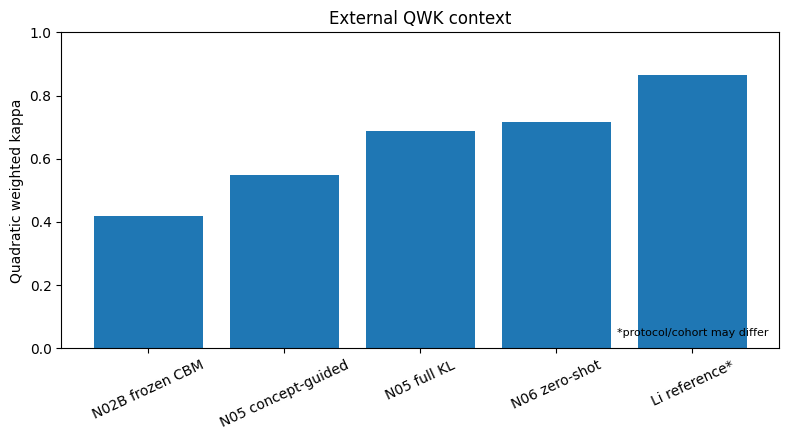

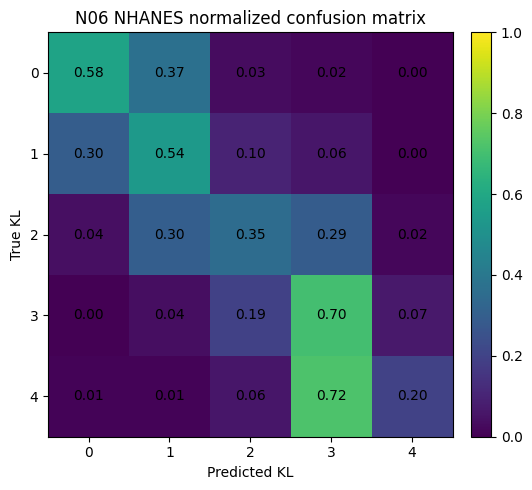

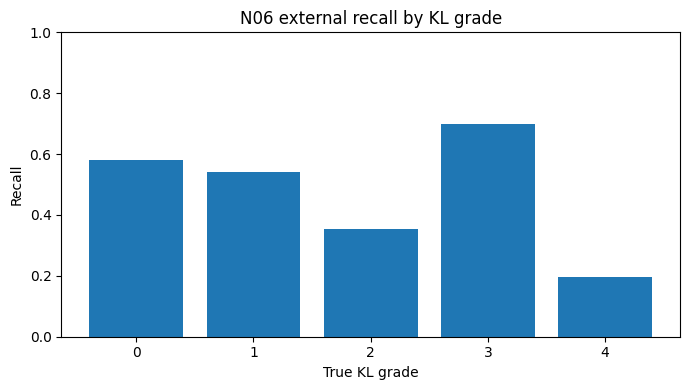

In [19]:
# 18. Final figures (default matplotlib styling; no hand-tuned colors)

# Figure 1: QWK context
fig, ax = plt.subplots(figsize=(8,4.5))
labels = ['N02B frozen CBM','N05 concept-guided','N05 full KL','N06 zero-shot','Li reference*']
values = [0.4188, 0.5499, 0.6872, EXTERNAL_METRICS['qwk'], CONFIG.li_reference_qwk]
ax.bar(labels, values)
ax.set_ylabel('Quadratic weighted kappa')
ax.set_ylim(0,1)
ax.set_title('External QWK context')
ax.tick_params(axis='x', rotation=25)
ax.text(4, 0.04, '*protocol/cohort may differ', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'F01_external_qwk_context.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'F01_external_qwk_context.pdf', bbox_inches='tight')
plt.show(); plt.close(fig)

# Figure 2: confusion matrix
cm = confusion_matrix(external_truth, external_pred, labels=[0,1,2,3,4], normalize='true')
fig, ax = plt.subplots(figsize=(5.5,5))
im = ax.imshow(cm, vmin=0, vmax=1)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xlabel('Predicted KL'); ax.set_ylabel('True KL'); ax.set_title('N06 NHANES normalized confusion matrix')
for i in range(5):
    for j in range(5):
        ax.text(j,i,f'{cm[i,j]:.2f}',ha='center',va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'F02_external_confusion_matrix.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'F02_external_confusion_matrix.pdf', bbox_inches='tight')
plt.show(); plt.close(fig)

# Figure 3: grade recall
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(GRADE_TABLE['kl_grade'].astype(str), GRADE_TABLE['recall'])
ax.set_ylim(0,1)
ax.set_xlabel('True KL grade'); ax.set_ylabel('Recall'); ax.set_title('N06 external recall by KL grade')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'F03_external_grade_recall.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'F03_external_grade_recall.pdf', bbox_inches='tight')
plt.show(); plt.close(fig)


# 14. N06 certificate

N06 can pass as an **executed exploratory stage** even if it does not reach 0.8640. Passing means the scientific and engineering protocol was respected:

- OAI-only model development;
- patient-disjoint split;
- all three final seeds retained;
- external lock written before NHANES loading;
- no target labels used for selection;
- required predictions, tables, figures and bootstrap intervals written;
- checkpoint and configuration hashes recorded.

Performance targets are reported as outcomes, not acceptance requirements.


In [20]:
# 19. Final certificate and artifact manifest

required_artifacts = [
    CONFIG_DIR / 'n06_config.json',
    CONFIG_DIR / 'n06_external_evaluation_lock.json',
    RESULT_DIR / 'selected_variant.json',
    RESULT_DIR / 'external_participant_bootstrap.csv',
    TABLE_DIR / 'T06_candidate_screen.csv',
    TABLE_DIR / 'T07_final_seed_validation.csv',
    TABLE_DIR / 'T09_external_performance.csv',
    TABLE_DIR / 'T10_external_bootstrap_intervals.csv',
    TABLE_DIR / 'T11_external_grade_recall.csv',
    PREDICTION_DIR / 'oai_validation_predictions.csv',
    PREDICTION_DIR / 'oai_test_predictions.csv',
    PREDICTION_DIR / 'nhanes_all_predictions.csv',
    FIGURE_DIR / 'F01_external_qwk_context.png',
    FIGURE_DIR / 'F02_external_confusion_matrix.png',
    FIGURE_DIR / 'F03_external_grade_recall.png',
]

artifact_rows=[]
for path in required_artifacts:
    artifact_rows.append({
        'path':str(path),
        'exists':path.exists(),
        'size_bytes':path.stat().st_size if path.exists() else None,
        'sha256':sha256_file(path) if path.exists() else None,
    })
ARTIFACT_MANIFEST = pd.DataFrame(artifact_rows)
atomic_csv(ARTIFACT_MANIFEST, RESULT_DIR / 'n06_artifact_manifest.csv')

criteria = {
    'N06 explicitly marked exploratory/post-hoc': True,
    'OAI patient split is disjoint': not bool(train_ids & val_ids or train_ids & test_ids or val_ids & test_ids),
    'three fixed final seeds are present': len(FINAL_RECORDS) == 3 and set(r['seed'] for r in FINAL_RECORDS) == set(CONFIG.training_seeds),
    'selected variant came from OAI validation only': SELECTED_VARIANT in VARIANTS,
    'external lock exists': LOCK_PATH.exists(),
    'lock states NHANES not used for selection': lock_check.get('nhanes_used_for_selection') is False,
    'all required artifacts exist': bool(ARTIFACT_MANIFEST['exists'].all()),
}
PASSED = all(criteria.values())

STATUS = {
    'stage':'N06',
    'protocol':PROTOCOL,
    'status':'PASS' if PASSED else 'FAIL',
    'exploratory_post_hoc':True,
    'selected_variant':SELECTED_VARIANT,
    'backbone':BACKBONE_NAME,
    'oai_validation_metrics':VAL_METRICS,
    'oai_validation_argmax_metrics':VAL_ARGMAX_METRICS,
    'oai_test_metrics':TEST_METRICS,
    'oai_test_argmax_metrics':TEST_ARGMAX_METRICS,
    'nhanes_all_metrics':EXTERNAL_METRICS,
    'li_reference_qwk':CONFIG.li_reference_qwk,
    'difference_from_li_reference':EXTERNAL_METRICS['qwk']-CONFIG.li_reference_qwk,
    'reference_comparability_caveat':BENCHMARK_NOTE,
    'criteria':criteria,
    'config_hash':CONFIG_HASH,
    'source_manifest_hash':SOURCE_MANIFEST_HASH,
    'split_hash':SPLIT_HASH,
    'external_lock_hash':FINAL_LOCK_HASH,
}
atomic_json(STATUS, RESULT_DIR / 'status.json')

certificate = [
    '='*78,
    'N06 PERFORMANCE CEILING AND EXTERNAL BENCHMARK CERTIFICATE',
    '='*78,
    f"Status: {STATUS['status']}",
    'Mode: EXPLORATORY / POST-HOC',
    f'Selected variant: {SELECTED_VARIANT}',
    f'Backbone: {BACKBONE_NAME}',
    f"OAI validation QWK: {VAL_METRICS['qwk']:.4f}",
    f"OAI test QWK (cutpoint primary): {TEST_METRICS['qwk']:.4f}",
    f"OAI test QWK (argmax sensitivity): {TEST_ARGMAX_METRICS['qwk']:.4f}",
    f"NHANES all-cohort zero-shot QWK (cutpoint primary): {EXTERNAL_METRICS['qwk']:.4f}",
    f"NHANES all-cohort zero-shot QWK (argmax sensitivity): {EXTERNAL_ARGMAX_METRICS['qwk']:.4f}",
    f"Li 2026 reference QWK: {CONFIG.li_reference_qwk:.4f} (NOT automatically protocol-matched)",
    '',
]
for key, value in criteria.items():
    certificate.append(f"{key:<58} {'PASS' if value else 'FAIL'}")
certificate += [
    '',
    f'Config SHA-256: {CONFIG_HASH}',
    f'OAI source-manifest SHA-256: {SOURCE_MANIFEST_HASH}',
    f'OAI split SHA-256: {SPLIT_HASH}',
    f'External-lock SHA-256: {FINAL_LOCK_HASH}',
    '',
    BENCHMARK_NOTE,
    '='*78,
]
certificate_text='\n'.join(certificate)
(RESULT_DIR / 'n06_certificate.txt').write_text(certificate_text, encoding='utf-8')
print(certificate_text)
display(ARTIFACT_MANIFEST)

if not PASSED:
    raise RuntimeError('N06 certificate failed. Repair only the failed protocol/artifact criteria.')


N06 PERFORMANCE CEILING AND EXTERNAL BENCHMARK CERTIFICATE
Status: PASS
Mode: EXPLORATORY / POST-HOC
Selected variant: baseline_ce
Backbone: convnext_base.fb_in22k_ft_in1k
OAI validation QWK: 0.8413
OAI test QWK (cutpoint primary): 0.8489
OAI test QWK (argmax sensitivity): 0.8349
NHANES all-cohort zero-shot QWK (cutpoint primary): 0.7150
NHANES all-cohort zero-shot QWK (argmax sensitivity): 0.6644
Li 2026 reference QWK: 0.8640 (NOT automatically protocol-matched)

N06 explicitly marked exploratory/post-hoc                 PASS
OAI patient split is disjoint                              PASS
three fixed final seeds are present                        PASS
selected variant came from OAI validation only             PASS
external lock exists                                       PASS
lock states NHANES not used for selection                  PASS
all required artifacts exist                               PASS

Config SHA-256: 7d599ff8a4a6853ac0205d1c0c701d2ddcaa3259c90f99b9629bc5bbe795cea9
O

,path,exists,size_bytes,sha256
0,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,1587,120403c5467bc2d07ab1660d83dab040bd948fcd08cd7c...
1,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,2925,e09381c28c306da6fb81d6cdad8cb2307e15fecd887dd7...
2,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,441,c968aeb229820661abffc887699c77b2f751e070804b93...
3,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,122216,cace3f6aab45862dd40b840c6b2f0ae258369750dc0d5a...
4,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,942,da641326548f3d3fcd7f5af57d3d77e9e64d1484a9ef24...
5,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,930,3b5115c1dec9a2436042a04975a82f568ace7ea5331cd8...
6,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,624,508ca51fafb8a3f955236dcb33c4e7be494f79b1059b05...
7,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,222,0ec33b470c8d339154314a69e7c41eef7acf602bd21333...
8,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,244,6c54401b6d5110a5aff90adaf3edada5e2eaf6eecc66f6...
9,/content/drive/MyDrive/MasterThesis/Final Pipe...,True,243736,cfeb5dca46be248cd86f4795e8025059bd118fb457a0cc...


## Interpretation template after execution

Use the executed result according to the following hierarchy:

- **External QWK < 0.70:** stronger direct modeling does not close most of the external gap; investigate data/protocol differences before adding architecture complexity.
- **0.70–0.79:** substantial recovery over the frozen CBM and a useful performance result.
- **0.80–0.839:** strong zero-shot transfer; most of the original performance deficit is recovered.
- **0.84–0.8639:** near the reported AGE-Net level, but cohort/protocol alignment is still required before a head-to-head claim.
- **≥ 0.864:** benchmark-level result; perform an aggressive duplicate, split, cohort-QC, label, and evaluation audit before claiming equality or superiority.
- **> 0.88:** treat leakage/protocol audit as mandatory before interpretation.

### What N06 does not prove

Even if N06 exceeds 0.8640 on the N01 NHANES cohort, it does not by itself establish superiority over Li et al. unless the external cohort construction and evaluation protocol are demonstrably comparable.
